In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

In [42]:
loan_dataset = pd.read_csv("C:/Uoload Docment/train_u6lujuX_CVtuZ9i (1).csv")
loan_dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [43]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [44]:
loan_dataset.shape

(614, 13)

In [45]:
loan_dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [46]:
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [47]:
loan_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [48]:
loan_dataset.dropna()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [49]:
le = LabelEncoder()
loan_dataset['Gender'] = le.fit_transform(loan_dataset['Gender'])
loan_dataset['Loan_Status'] = le.fit_transform(loan_dataset['Loan_Status'])
print(loan_dataset)


      Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002       1      No          0      Graduate            No   
1    LP001003       1     Yes          1      Graduate            No   
2    LP001005       1     Yes          0      Graduate           Yes   
3    LP001006       1     Yes          0  Not Graduate            No   
4    LP001008       1      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978       0      No          0      Graduate            No   
610  LP002979       1     Yes         3+      Graduate            No   
611  LP002983       1     Yes          1      Graduate            No   
612  LP002984       1     Yes          2      Graduate            No   
613  LP002990       0      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN           

In [50]:
loan_dataset['Dependents'].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [51]:
loan_dataset = loan_dataset.replace(to_replace='3+', value=4)

In [52]:
loan_dataset['Dependents'].value_counts()

Dependents
0    345
1    102
2    101
4     51
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

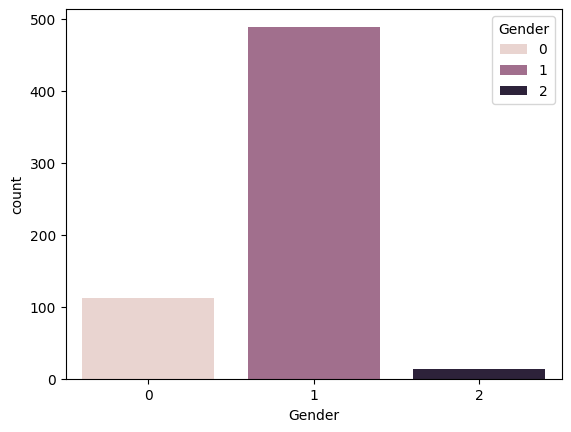

In [53]:
# Gender Distribution How many males vs females applied for a loan?
sns.countplot(x='Gender', hue='Gender', data=loan_dataset)

<Axes: xlabel='Education', ylabel='count'>

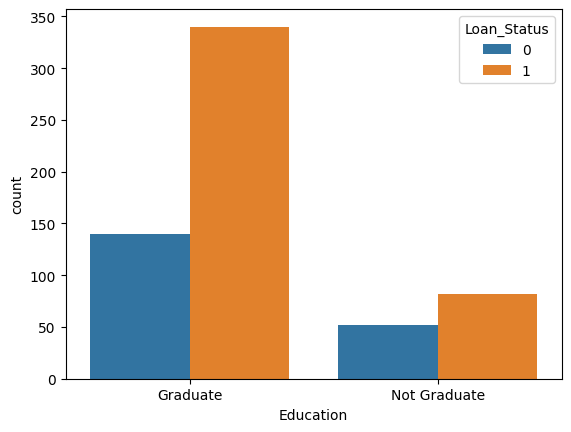

In [19]:
# education And loan Status
sns.countplot(x='Education', hue='Loan_Status',data=loan_dataset)

<Axes: xlabel='Married', ylabel='count'>

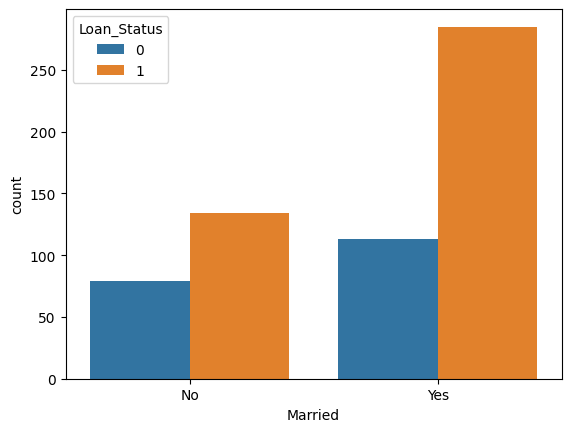

In [20]:
# Married vs Single
sns.countplot(x='Married',hue='Loan_Status',data=loan_dataset)

<Axes: xlabel='Credit_History', ylabel='count'>

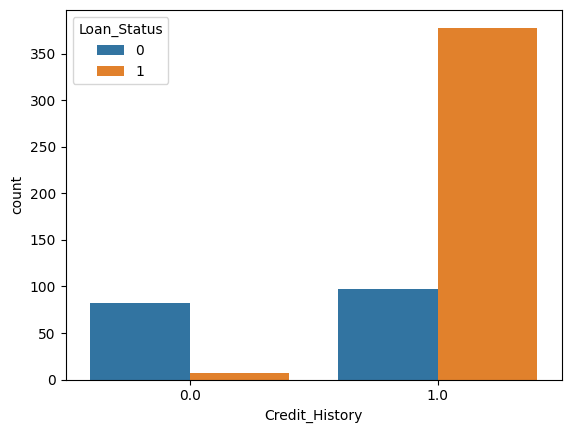

In [30]:
# credit histroy influence
sns.countplot(x='Credit_History', hue='Loan_Status', data=loan_dataset)

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

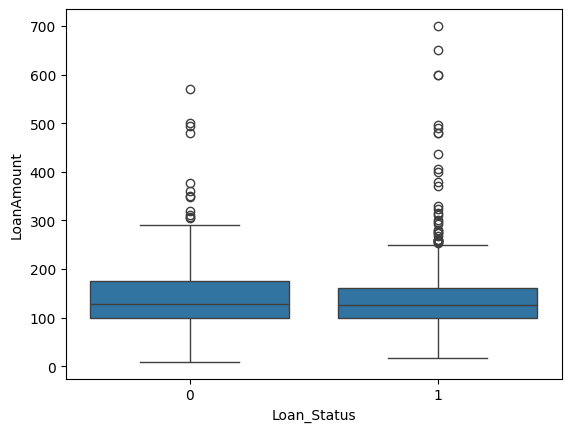

In [31]:
# loan Amount vs Approval
sns.boxplot(x='Loan_Status', y='LoanAmount', data=loan_dataset)

In [54]:
le = LabelEncoder()
loan_dataset['Married'] = le.fit_transform(loan_dataset['Married'])
loan_dataset['Education'] = le.fit_transform(loan_dataset['Education'])
loan_dataset['Self_Employed'] = le.fit_transform(loan_dataset['Self_Employed'])
loan_dataset['Property_Area'] = le.fit_transform(loan_dataset['Property_Area'])
                                                 
print(loan_dataset)


      Loan_ID  Gender  Married Dependents  Education  Self_Employed  \
0    LP001002       1        0          0          0              0   
1    LP001003       1        1          1          0              0   
2    LP001005       1        1          0          0              1   
3    LP001006       1        1          0          1              0   
4    LP001008       1        0          0          0              0   
..        ...     ...      ...        ...        ...            ...   
609  LP002978       0        0          0          0              0   
610  LP002979       1        1          4          0              0   
611  LP002983       1        1          1          0              0   
612  LP002984       1        1          2          0              0   
613  LP002990       0        0          0          0              1   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849                0.0         NaN             360.0   
1

In [56]:
# separating the data and label
X = loan_dataset.drop(columns=['Loan_ID','Loan_Status'],axis=1)
Y = loan_dataset['Loan_Status']
print(X)
print(Y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0          0          0              0             5849   
1         1        1          1          0              0             4583   
2         1        1          0          0              1             3000   
3         1        1          0          1              0             2583   
4         1        0          0          0              0             6000   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          0              0             2900   
610       1        1          4          0              0             4106   
611       1        1          1          0              0             8072   
612       1        1          2          0              0             7583   
613       0        0          0          0              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [58]:
# Features and target
X = loan_dataset.drop(columns=['Loan_ID','Loan_Status'])
y = loan_dataset['Loan_Status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model
model = svm.SVC()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")


Model Accuracy: 65.04%


In [60]:
# Take user input for new loan application
print("Enter applicant details below to predict loan approval:\n")

gender = int(input("Gender (0 = Female, 1 = Male): "))
married = int(input("Married (0 = No, 1 = Yes): "))
dependents = int(input("Number of Dependents (0,1,2,3): "))
education = int(input("Education (0 = Not Graduate, 1 = Graduate): "))
self_employed = int(input("Self Employed (0 = No, 1 = Yes): "))
applicant_income = float(input("Applicant Income: "))
coapplicant_income = float(input("Coapplicant Income: "))
loan_amount = float(input("Loan Amount: "))
loan_term = float(input("Loan Amount Term (e.g., 360): "))
credit_history = int(input("Credit History (0 = No, 1 = Yes): "))
property_area = int(input("Property Area (0 = Rural, 1 = Semiurban, 2 = Urban): "))

# Create a dataframe for new data
new_data = pd.DataFrame({
    'Gender':[gender],
    'Married':[married],
    'Dependents':[dependents],
    'Education':[education],
    'Self_Employed':[self_employed],
    'ApplicantIncome':[applicant_income],
    'CoapplicantIncome':[coapplicant_income],
    'LoanAmount':[loan_amount],
    'Loan_Amount_Term':[loan_term],
    'Credit_History':[credit_history],
    'Property_Area':[property_area]
})

# Predict
result = model.predict(new_data)[0]

# Output prediction
if result == 1:
    print("\n✅ Loan is likely to be Approved.")
else:
    print("\n❌ Loan is likely to be Rejected.")


Enter applicant details below to predict loan approval:



Gender (0 = Female, 1 = Male):  1
Married (0 = No, 1 = Yes):  1
Number of Dependents (0,1,2,3):  0
Education (0 = Not Graduate, 1 = Graduate):  0
Self Employed (0 = No, 1 = Yes):  1
Applicant Income:  5000
Coapplicant Income:  1500
Loan Amount:  1000
Loan Amount Term (e.g., 360):  360
Credit History (0 = No, 1 = Yes):  1
Property Area (0 = Rural, 1 = Semiurban, 2 = Urban):  0



✅ Loan is likely to be Approved.


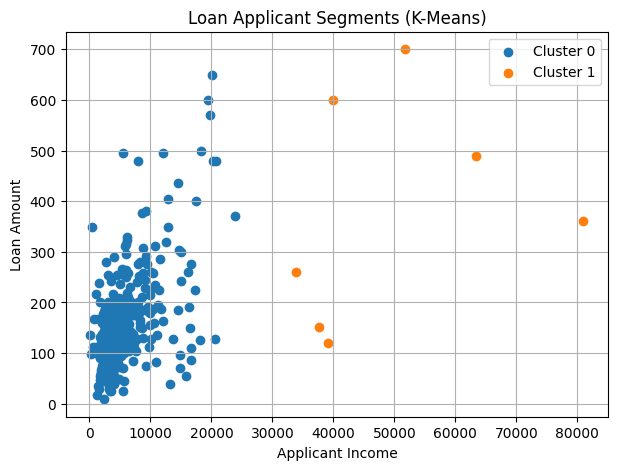

In [65]:

X = loan_dataset[['ApplicantIncome', 'LoanAmount']]

# Fit K-Means clustering
model = KMeans(n_clusters=2, random_state=42, n_init=10)
loan_dataset['Cluster'] = model.fit_predict(X)

# Visualize clusters
plt.figure(figsize=(7,5))
for cluster in loan_dataset['Cluster'].unique():
    cluster_data = loan_dataset[loan_dataset['Cluster'] == cluster]
    plt.scatter(cluster_data['ApplicantIncome'], cluster_data['LoanAmount'], label=f'Cluster {cluster}')

plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.title('Loan Applicant Segments (K-Means)')
plt.legend()
plt.grid(True)
plt.show()
